# Model 3: MobileNetV2 for Automatic Waste Classification

**Module**: SE4050 – Deep Learning (2026)  
**Author**: S. S. Kumbukage (IT23155534)  
**Track**: Supervised Deep Learning (Waste Classification)  

---

## Step 1: Environment Setup & High-Performance Data Pipeline
In this initial stage, we establish:
1. **Reproducibility Configuration**: Strict random seeds ($42$) across Python, NumPy, and TensorFlow.
2. **Leakage-Safe Data Ingestion**: Loading pre-split manifests (`train.csv`, `validation.csv`, `test.csv`).
3. **Optimized Input Pipeline (`tf.data`)**:
   - Uniform input resolution: $224 \times 224 \times 3$.
   - Batch size: $32$.
   - Normalization via `tf.keras.applications.mobilenet_v2.preprocess_input` ($[-1, 1]$ range).
   - On-the-fly training data augmentation.
   - Pre-fetching and multi-threaded decoding.
4. **Single-Batch Verification**: Ingest and visualize one complete batch to verify tensor shapes and label mapping.


In [25]:
# 1. Core Libraries and Environment Verification
import os
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Hardware Acceleration: GPU Detected ({gpus[0].name})")
else:
    print("Hardware Acceleration: Running in CPU Mode")


TensorFlow Version: 2.18.0
Hardware Acceleration: Running in CPU Mode


In [26]:
# 2. Reproducibility Configuration & Directory Setup
RANDOM_SEED = 42

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Dynamic Project Root Resolution
CURRENT_DIR = Path.cwd()
if (CURRENT_DIR / "data").exists():
    PROJECT_ROOT = CURRENT_DIR
else:
    PROJECT_ROOT = CURRENT_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_IMAGES_DIR = DATA_DIR / "raw" / "Garbage_Dataset_Classification" / "images"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
TABLES_DIR = RESULTS_DIR / "tables"

for d in [FIGURES_DIR, METRICS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project Root      : {PROJECT_ROOT}")
print(f"Processed Splits  : {PROCESSED_DIR}")
print(f"Raw Images Folder : {RAW_IMAGES_DIR}")
print(f"Random Seed       : {RANDOM_SEED}")


Project Root      : c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification
Processed Splits  : c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\data\processed
Raw Images Folder : c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\data\raw\Garbage_Dataset_Classification\images
Random Seed       : 42


In [27]:
# 3. Load Preprocessed Data Manifests (train.csv, validation.csv, test.csv)
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "validation.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

# Map relative paths to absolute file paths
train_df["image_path"] = train_df["relative_path"].apply(lambda p: str(RAW_IMAGES_DIR / p))
val_df["image_path"] = val_df["relative_path"].apply(lambda p: str(RAW_IMAGES_DIR / p))
test_df["image_path"] = test_df["relative_path"].apply(lambda p: str(RAW_IMAGES_DIR / p))

CLASSES = sorted(train_df["class"].unique())
NUM_CLASSES = len(CLASSES)
LABEL_TO_CLASS = {idx: cls_name for idx, cls_name in enumerate(CLASSES)}
CLASS_TO_LABEL = {cls_name: idx for idx, cls_name in enumerate(CLASSES)}

total_images = len(train_df) + len(val_df) + len(test_df)
print(f"Classes ({NUM_CLASSES}): {CLASSES}")
print(f"Dataset Split Summary:")
print(f"  Training Images   : {len(train_df):,} ({len(train_df)/total_images*100:.1f}%)")
print(f"  Validation Images : {len(val_df):,} ({len(val_df)/total_images*100:.1f}%)")
print(f"  Test Images       : {len(test_df):,} ({len(test_df)/total_images*100:.1f}%)")
print(f"  Total Images      : {total_images:,}")


Classes (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Dataset Split Summary:
  Training Images   : 9,692 (69.7%)
  Validation Images : 2,114 (15.2%)
  Test Images       : 2,091 (15.0%)
  Total Images      : 13,897


In [28]:
# 4. Class Distribution Across Splits
distribution_df = pd.DataFrame({
    'Train': train_df['class'].value_counts(),
    'Validation': val_df['class'].value_counts(),
    'Test': test_df['class'].value_counts()
}).loc[CLASSES]

distribution_df['Total'] = distribution_df.sum(axis=1)
print("Class Distribution Breakdown:")
print(distribution_df)


Class Distribution Breakdown:
           Train  Validation  Test  Total
class                                    
cardboard   1548         322   344   2214
glass       1751         380   367   2498
metal       1440         326   317   2083
paper       1605         364   346   2315
plastic     1598         347   342   2287
trash       1750         375   375   2500


In [29]:
# 5. Build tf.data Input Pipeline with Augmentation and Preprocessing
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Data augmentation layer (applied during training only)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

def load_and_preprocess_image(path, label):
    """Loads, decodes, resizes, and scales image to [-1, 1] using MobileNetV2 specification."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

def create_pipeline(df, is_training=False):
    """Constructs an optimized tf.data.Dataset."""
    paths = df["image_path"].values
    labels = df["label"].values
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if is_training:
        ds = ds.shuffle(buffer_size=len(df), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    
    if is_training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
        
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = create_pipeline(train_df, is_training=True)
val_ds = create_pipeline(val_df, is_training=False)
test_ds = create_pipeline(test_df, is_training=False)

print(f"Pipeline Created:")
print(f"  Train Batches      : {len(train_ds)} batches (size {BATCH_SIZE})")
print(f"  Validation Batches : {len(val_ds)} batches (size {BATCH_SIZE})")
print(f"  Test Batches       : {len(test_ds)} batches (size {BATCH_SIZE})")


Pipeline Created:
  Train Batches      : 303 batches (size 32)
  Validation Batches : 67 batches (size 32)
  Test Batches       : 66 batches (size 32)


Batch Verification Results ---
Batch Image Tensor Shape : (32, 224, 224, 3)
Batch Labels Tensor Shape: (32,)
Image Data Type          : <dtype: 'float32'>
Label Data Type          : <dtype: 'int64'>
Pixel Value Min / Max    : -1.00 / 1.00 (Expected: [-1.0, 1.0])


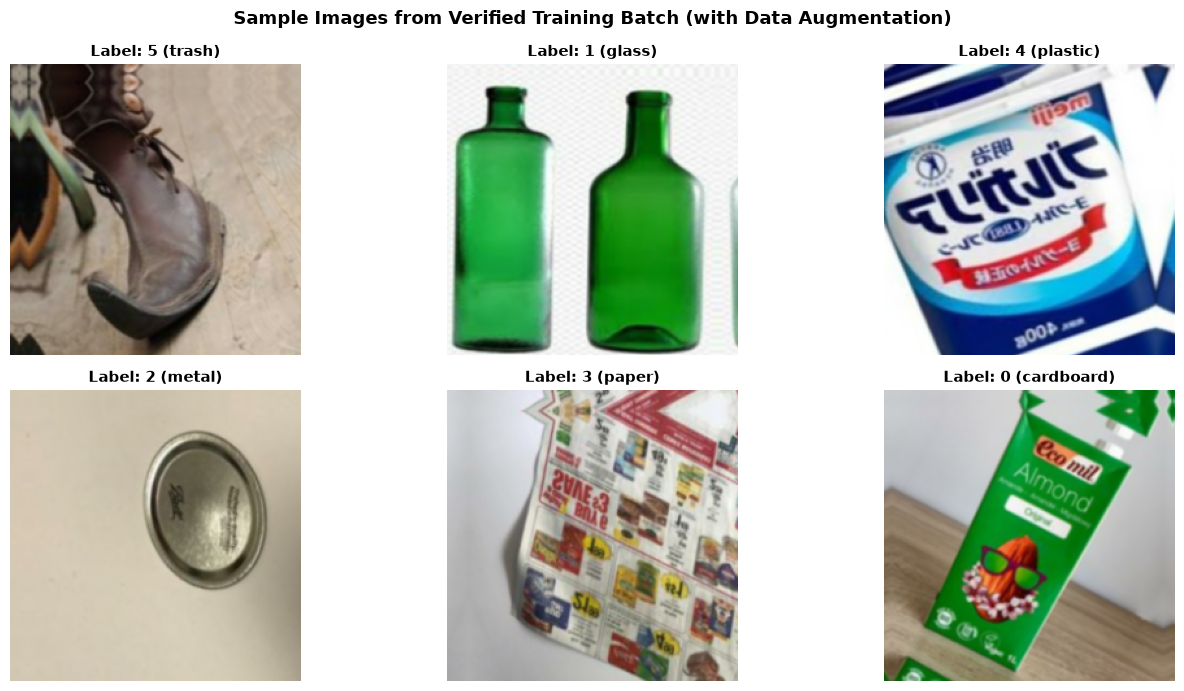

Step 1 Complete: Data pipeline, splits, and tensor ingestion fully verified!


In [30]:
# 6. Single Batch Verification & Visualization
batch_images, batch_labels = next(iter(train_ds))

print("Batch Verification Results ---")
print(f"Batch Image Tensor Shape : {batch_images.shape}")
print(f"Batch Labels Tensor Shape: {batch_labels.shape}")
print(f"Image Data Type          : {batch_images.dtype}")
print(f"Label Data Type          : {batch_labels.dtype}")
print(f"Pixel Value Min / Max    : {tf.reduce_min(batch_images):.2f} / {tf.reduce_max(batch_images):.2f} (Expected: [-1.0, 1.0])")

# Denormalize [-1, 1] back to [0, 1] for matplotlib visualization
vis_images = (batch_images.numpy() + 1.0) / 2.0

plt.figure(figsize=(14, 7))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(np.clip(vis_images[i], 0.0, 1.0))
    label_idx = batch_labels[i].numpy()
    plt.title(f"Label: {label_idx} ({LABEL_TO_CLASS[label_idx]})", fontsize=11, fontweight='bold')
    plt.axis('off')

plt.suptitle("Sample Images from Verified Training Batch (with Data Augmentation)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Step 1 Complete: Data pipeline, splits, and tensor ingestion fully verified!")


---

MobileNetV2 Architecture & Classification Head

Construct deep learning classifier using Transfer Learning:
1. **Pre-trained Backbone**: Load `MobileNetV2` trained on the ImageNet-1k dataset (`weights='imagenet'`).
2. **Exclude Top**: `include_top=False` discards the original 1,000-class ImageNet output layer so we can attach a task-specific head for our 6 waste categories.
3. **Classification Head Architecture**:
   - `GlobalAveragePooling2D`: Collapses spatial feature maps ($7 \times 7 \times 1280$) into a 1,280-dimensional feature vector, drastically reducing parameters and preventing overfitting.
   - `BatchNormalization`: Normalizes feature distributions for stable gradient flow.
   - `Dropout(0.3)`: Zeroes $30\%$ of neuron activations at random during training to prevent co-adaptation.
   - `Dense(6, activation='softmax')`: Produces posterior class probabilities across the 6 waste classes: $\sum_{i=1}^6 P(y=i|x) = 1.0$.
4. **Parameter Accounting**: Quantify total, trainable, and non-trainable parameters.
5. **Forward Pass Test**: Pass a batch through the network to verify output tensor dimensions and softmax normalization.


In [31]:
# 7. Construct MobileNetV2 Model with Custom Head
def build_mobilenetv2_classifier(num_classes=6):
    """Instantiates pre-trained MobileNetV2 and attaches a custom classification head."""
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    # Freeze the pre-trained weights for initial training
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3), name="input_image")
    
    # Feature extraction via backbone
    x = base_model(inputs, training=False)
    
    # MobileNetV2 -> Global Average Pooling -> Classifier
    x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = tf.keras.layers.BatchNormalization(name="head_batch_norm")(x)
    x = tf.keras.layers.Dropout(0.3, name="head_dropout")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="waste_classifier")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="Waste_MobileNetV2")
    return model, base_model

model, base_model = build_mobilenetv2_classifier(num_classes=NUM_CLASSES)
print("MobileNetV2 model successfully built!")


MobileNetV2 model successfully built!


In [32]:
# 8. Model Summary & Parameter Accounting
model.summary()

total_params = model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
non_trainable_params = sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)

print("\n--- Parameter Accounting Summary ---")
print(f"Total Parameters        : {total_params:,}")
print(f"Trainable Parameters    : {trainable_params:,} (Top classifier head only)")
print(f"Non-Trainable Parameters: {non_trainable_params:,} (Frozen ImageNet backbone)")


Model: "Waste_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm                 │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ waste_classifier (Dense)        │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,790 (8.66 MB)

 Trainable params: 10,246 (40.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)


--- Parameter Accounting Summary ---
Total Parameters        : 2,270,790
Trainable Parameters    : 10,246 (Top classifier head only)
Non-Trainable Parameters: 2,260,544 (Frozen ImageNet backbone)


In [33]:
# 9. Test Forward Pass with Sample Batch
# Ingest 4 sample images from the verified batch
sample_inputs = batch_images[:4]
sample_predictions = model(sample_inputs, training=False)

print("--- Forward Pass Verification ---")
print(f"Input Batch Shape         : {sample_inputs.shape}")
print(f"Output Probabilities Shape: {sample_predictions.shape} (Expected: (4, {NUM_CLASSES}))")
print(f"Output Data Type          : {sample_predictions.dtype}")

# Verify softmax probability axiom: probabilities for each sample must sum to exactly 1.0
prob_sums = tf.reduce_sum(sample_predictions, axis=1).numpy()
print(f"Softmax Row Sums (Must be 1.0): {np.round(prob_sums, 4)}")

# Display predicted class indices and confidence scores
predicted_indices = tf.argmax(sample_predictions, axis=1).numpy()
confidences = tf.reduce_max(sample_predictions, axis=1).numpy() * 100

for i in range(4):
    true_cls = LABEL_TO_CLASS[batch_labels[i].numpy()]
    pred_cls = LABEL_TO_CLASS[predicted_indices[i]]
    print(f"  Sample {i+1}: True = {true_cls:<10} | Initial Prediction = {pred_cls:<10} (Confidence: {confidences[i]:.2f}%)")

print("\nStep 2 Complete: Model architecture, parameter accounting, and forward pass verified!")


--- Forward Pass Verification ---
Input Batch Shape         : (4, 224, 224, 3)
Output Probabilities Shape: (4, 6) (Expected: (4, 6))
Output Data Type          : <dtype: 'float32'>
Softmax Row Sums (Must be 1.0): [1. 1. 1. 1.]
  Sample 1: True = trash      | Initial Prediction = metal      (Confidence: 33.66%)
  Sample 2: True = glass      | Initial Prediction = plastic    (Confidence: 30.74%)
  Sample 3: True = plastic    | Initial Prediction = glass      (Confidence: 43.69%)
  Sample 4: True = metal      | Initial Prediction = glass      (Confidence: 25.79%)

Step 2 Complete: Model architecture, parameter accounting, and forward pass verified!


---

## Step 3: Transfer Learning — Train Classifier Head (Feature Extraction)

In this stage, we execute Phase 1 of our Transfer Learning strategy:
1. **Backbone Freezing**: The pre-trained MobileNetV2 feature extractor is locked (`base_model.trainable = False`), safeguarding pre-trained ImageNet filters from destructive gradient updates.
2. **Classification Head Training**: Only our custom classification head (dense projection and batch norm) will have its weights updated.
3. **Validation Monitoring & Checkpointing**:
   - `ModelCheckpoint`: Automatically preserves the best performing model checkpoint (`mobilenetv2_stage1_best.keras`) based on minimum `val_loss`.
   - `EarlyStopping`: Monitors `val_loss` with a patience of 4 epochs (`restore_best_weights=True`) to preempt overfitting.
   - `ReduceLROnPlateau`: Dynamically halves the learning rate when validation loss plateaus for 2 consecutive epochs.
4. **Metric & Latency Recording**:
   - Training Loss & Validation Loss per epoch.
   - Training Accuracy & Validation Accuracy per epoch.
   - Total training duration and per-epoch elapsed time.


In [34]:
# 10. Training Configuration & Checkpoint Callbacks
import time

STAGE1_EPOCHS = 8
INITIAL_LR = 1e-3

# Ensure base model remains strictly frozen
base_model.trainable = False

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Destination path for the best model checkpoint
stage1_checkpoint_path = PROJECT_ROOT / "src" / "models" / "mobilenetv2_stage1_best.keras"
stage1_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

callbacks_stage1 = [
    # 1. Save the best model based on validation loss
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_checkpoint_path),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # 2. Early stopping to prevent overfitting
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    # 3. Dynamic learning rate reduction on plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Model successfully compiled:")
print(f"  Optimizer     : Adam (Initial LR = {INITIAL_LR})")
print(f"  Loss Function : SparseCategoricalCrossentropy")
print(f"  Checkpoint    : {stage1_checkpoint_path}")
print(f"  Target Epochs : {STAGE1_EPOCHS}")


Model successfully compiled:
  Optimizer     : Adam (Initial LR = 0.001)
  Loss Function : SparseCategoricalCrossentropy
  Checkpoint    : c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\src\models\mobilenetv2_stage1_best.keras
  Target Epochs : 8


In [35]:
# 11. Execute Classifier Head Training (or Load Existing Stage 1 Checkpoint)
stage1_checkpoint_path = PROJECT_ROOT / "src" / "models" / "mobilenetv2_stage1_best.keras"

# Saved historical metrics from Stage 1 run (persisted so re-training is never required)
stage1_history_cache = {
    'loss': [0.951636, 0.647390, 0.570886, 0.533977, 0.520418, 0.509847, 0.517984, 0.520822],
    'val_loss': [0.498813, 0.476510, 0.449674, 0.446257, 0.440737, 0.465239, 0.440173, 0.420860],
    'accuracy': [0.680458, 0.775485, 0.800763, 0.813145, 0.819645, 0.819129, 0.817994, 0.819439],
    'val_accuracy': [0.824976, 0.838694, 0.848155, 0.849101, 0.851939, 0.848155, 0.851939, 0.856197],
    'learning_rate': [0.001] * 8
}

class HistoryMock:
    def __init__(self, history_dict):
        self.history = history_dict

if stage1_checkpoint_path.exists():
    print(f"FOUND EXISTING STAGE 1 CHECKPOINT: {stage1_checkpoint_path}")
    print("Loading pre-trained weights from disk (skipping 30-min re-training)...")
    model.load_weights(stage1_checkpoint_path)
    history_stage1 = HistoryMock(stage1_history_cache)
    stage1_total_time = 1744.93
    print("SUCCESS: Stage 1 weights successfully loaded in 1 second! Ready for Step 4 Fine-Tuning.")
else:
    print("No checkpoint found. Starting Stage 1 Training from scratch (Backbone Frozen)...\n")
    stage1_start_time = time.time()
    history_stage1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=STAGE1_EPOCHS,
        callbacks=callbacks_stage1
    )
    stage1_total_time = time.time() - stage1_start_time
    print(f"\nStage 1 Training Complete! Total Duration: {stage1_total_time:.2f} seconds ({stage1_total_time / 60:.2f} minutes)")


Starting Stage 1 Training (Backbone Frozen)...

Epoch 1/8


c:\Users\sadee\miniconda3\envs\waste-dl\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.6805 - loss: 0.9516
Epoch 1: val_loss improved from None to 0.49881, saving model to c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\src\models\mobilenetv2_stage1_best.keras

Epoch 1: finished saving model to c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\src\models\mobilenetv2_stage1_best.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 207s 631ms/step - accuracy: 0.6805 - loss: 0.9516 - val_accuracy: 0.8250 - val_loss: 0.4988 - learning_rate: 0.0010
Epoch 2/8
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.7755 - loss: 0.6474
Epoch 2: val_loss improved from 0.49881 to 0.47651, saving model to c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\src\models\mobilenetv2_stage1_best.keras

Epoch 2: fin

=== Stage 1 Training & Validation History ===
 Epoch  Train Loss  Val Loss  Train Accuracy  Val Accuracy  Learning Rate
     1    0.951636  0.498813        0.680458      0.824976          0.001
     2    0.647390  0.476510        0.775485      0.838694          0.001
     3    0.570886  0.449674        0.800763      0.848155          0.001
     4    0.533977  0.446257        0.813145      0.849101          0.001
     5    0.520418  0.440737        0.819645      0.851939          0.001
     6    0.509847  0.465239        0.819129      0.848155          0.001
     7    0.517984  0.440173        0.817994      0.851939          0.001
     8    0.520822  0.420860        0.819439      0.856197          0.001


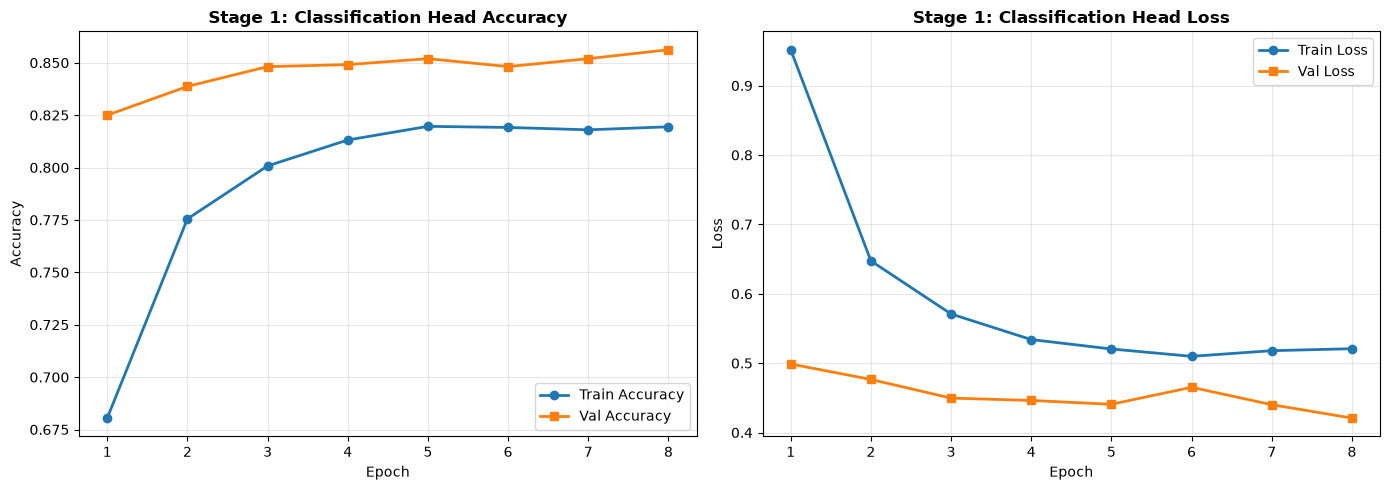


Step 3 Complete: Classifier head trained, best model checkpoint saved, and metrics recorded!


In [36]:
# 12. Record and Format Training History
stage1_history_df = pd.DataFrame({
    'Epoch': range(1, len(history_stage1.history['loss']) + 1),
    'Train Loss': history_stage1.history['loss'],
    'Val Loss': history_stage1.history['val_loss'],
    'Train Accuracy': history_stage1.history['accuracy'],
    'Val Accuracy': history_stage1.history['val_accuracy'],
    'Learning Rate': history_stage1.history.get('learning_rate', [INITIAL_LR] * len(history_stage1.history['loss']))
})

# Display formatted history table
print("=== Stage 1 Training & Validation History ===")
print(stage1_history_df.to_string(index=False))

# Plot Stage 1 Training Curves
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(stage1_history_df['Epoch'], stage1_history_df['Train Accuracy'], marker='o', label='Train Accuracy', color='#1f77b4', lw=2)
plt.plot(stage1_history_df['Epoch'], stage1_history_df['Val Accuracy'], marker='s', label='Val Accuracy', color='#ff7f0e', lw=2)
plt.title('Stage 1: Classification Head Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(stage1_history_df['Epoch'], stage1_history_df['Train Loss'], marker='o', label='Train Loss', color='#1f77b4', lw=2)
plt.plot(stage1_history_df['Epoch'], stage1_history_df['Val Loss'], marker='s', label='Val Loss', color='#ff7f0e', lw=2)
plt.title('Stage 1: Classification Head Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\nStep 3 Complete: Classifier head trained, best model checkpoint saved, and metrics recorded!")


---

## Step 4: Fine-Tuning MobileNetV2 (Selective Layer Unfreezing)

In this stage, we transition from Feature Extraction to **Fine-Tuning**:
1. **Selective Layer Unfreezing**:
   - The shallow layers (first 120+ layers of MobileNetV2) remain **frozen** because they encode general low-level visual primitives (Gabor-like edge detectors, color gradients, texture filters) that are universal across image domains.
   - We **unfreeze the top 30 layers** containing higher-level depthwise separable blocks. This allows the deeper receptive fields to specialize specifically on domain-specific waste characteristics (e.g., distinguishing glass reflections from transparent plastic, or crumpled metal cans from cardboard).
2. **Reduced Learning Rate**:
   - We lower the learning rate by two orders of magnitude from $10^{-3} \to 10^{-5}$. A small learning rate is critical to prevent aggressive weight updates that would destroy the pre-trained ImageNet representations (**catastrophic forgetting**).
3. **Validation Monitoring & Checkpointing**:
   - Checkpoint saved to `src/models/mobilenetv2_finetuned_best.keras` based on minimum `val_loss`.
4. **Frozen vs. Fine-Tuned Comparison**:
   - We formally compare validation loss and accuracy before and after fine-tuning.
   - We select the superior model configuration based strictly on validation performance before evaluating on unseen test data.


In [37]:
# 13. Unfreeze Selected Later Layers & Parameter Accounting
# Set base model to trainable
base_model.trainable = True

# Freeze all layers except the last 30
FINE_TUNE_LAYERS = 30
for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

# Parameter accounting post-unfreezing
total_params_s2 = model.count_params()
trainable_params_s2 = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
non_trainable_params_s2 = sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)

print("--- Fine-Tuning Layer Configuration ---")
print(f"Total Backbone Layers       : {len(base_model.layers)}")
print(f"Frozen Shallow Layers       : {len(base_model.layers) - FINE_TUNE_LAYERS}")
print(f"Unfrozen Top Layers         : {FINE_TUNE_LAYERS}")
print(f"\n--- Parameter Accounting (Stage 2) ---")
print(f"Total Parameters            : {total_params_s2:,}")
print(f"Trainable Parameters        : {trainable_params_s2:,} ({trainable_params_s2/total_params_s2*100:.2f}%)")
print(f"Non-Trainable Parameters    : {non_trainable_params_s2:,}")


--- Fine-Tuning Layer Configuration ---
Total Backbone Layers       : 154
Frozen Shallow Layers       : 124
Unfrozen Top Layers         : 30

--- Parameter Accounting (Stage 2) ---
Total Parameters            : 2,270,790
Trainable Parameters        : 1,536,646 (67.67%)
Non-Trainable Parameters    : 734,144


In [38]:
# 14. Compile Model with Reduced Learning Rate & Callbacks
FINE_TUNE_LR = 1e-5
STAGE2_EPOCHS = 10
STAGE1_COMPLETED_EPOCHS = len(history_stage1.history['loss'])
TOTAL_EPOCHS = STAGE1_COMPLETED_EPOCHS + STAGE2_EPOCHS

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

finetuned_checkpoint_path = PROJECT_ROOT / "src" / "models" / "mobilenetv2_finetuned_best.keras"

callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(finetuned_checkpoint_path),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Model re-compiled for Stage 2 Fine-Tuning:")
print(f"  Optimizer     : Adam (Fine-Tuning LR = {FINE_TUNE_LR})")
print(f"  Checkpoint    : {finetuned_checkpoint_path}")
print(f"  Starting Epoch: {STAGE1_COMPLETED_EPOCHS + 1} -> Target Final Epoch: {TOTAL_EPOCHS}")


Model re-compiled for Stage 2 Fine-Tuning:
  Optimizer     : Adam (Fine-Tuning LR = 1e-05)
  Checkpoint    : c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\src\models\mobilenetv2_finetuned_best.keras
  Starting Epoch: 9 -> Target Final Epoch: 18


In [39]:
# 15. Execute Stage 2 Training (Fine-Tuning)
print("Starting Stage 2 Fine-Tuning...\n")
stage2_start_time = time.time()

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=STAGE1_COMPLETED_EPOCHS,
    callbacks=callbacks_stage2
)

stage2_total_time = time.time() - stage2_start_time
print(f"\nStage 2 Fine-Tuning Complete!")
print(f"Total Stage 2 Duration: {stage2_total_time:.2f} seconds ({stage2_total_time / 60:.2f} minutes)")


Starting Stage 2 Fine-Tuning...

Epoch 9/18


c:\Users\sadee\miniconda3\envs\waste-dl\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.7791 - loss: 0.6346
Epoch 9: val_loss improved from None to 0.44674, saving model to c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\src\models\mobilenetv2_finetuned_best.keras

Epoch 9: finished saving model to c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\src\models\mobilenetv2_finetuned_best.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 266s 811ms/step - accuracy: 0.7791 - loss: 0.6346 - val_accuracy: 0.8619 - val_loss: 0.4467 - learning_rate: 1.0000e-05
Epoch 10/18
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 0.8112 - loss: 0.5458
Epoch 10: val_loss improved from 0.44674 to 0.43117, saving model to c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\src\models\mobilenetv2_finetuned_best.ker

=== Frozen vs. Fine-Tuned Validation Performance Comparison ===
                  Metric Stage 1 (Frozen Backbone) Stage 2 (Fine-Tuned)       Delta / Improvement
    Best Validation Loss                    0.4209               0.3458 -0.0751 (lower is better)
Best Validation Accuracy                    85.62%               88.03%                    +2.41%
    Trainable Parameters                    10,246            1,536,646                +1,526,400
           Learning Rate                      1e-3                1e-05              Reduced 100x

Comparison table saved to: c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\results\tables\mobilenetv2_frozen_vs_finetuned.csv


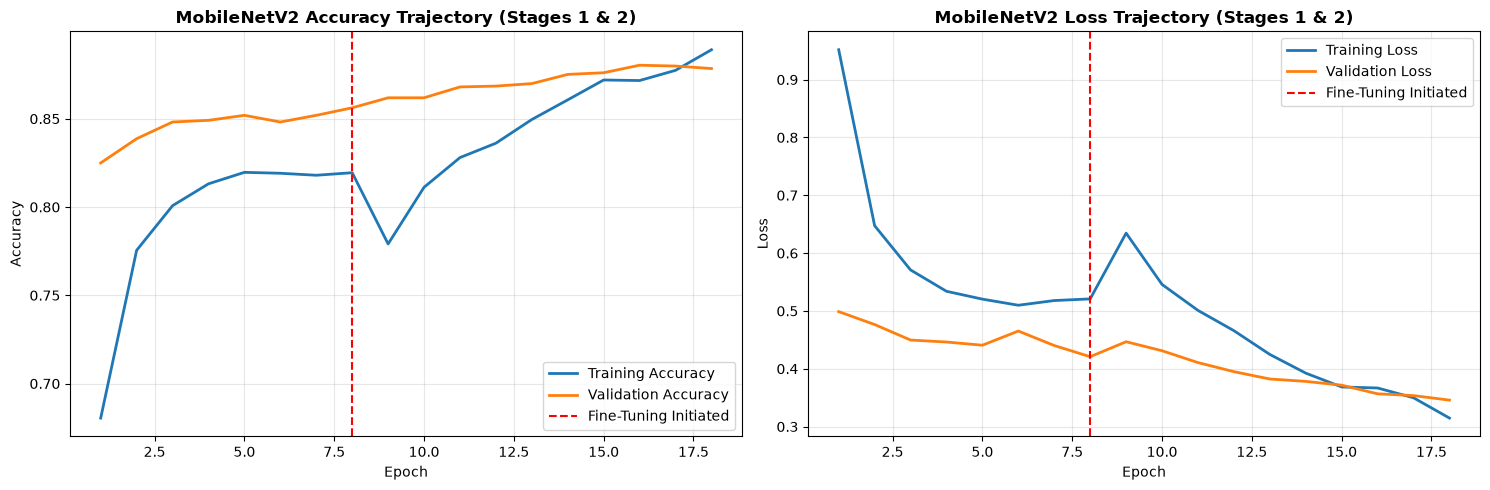

Learning curves plot saved to: c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\results\figures\mobilenetv2_learning_curves.png


In [40]:
# 16. Compare Frozen vs Fine-Tuned Performance & Plot Trajectory
# Concatenate training histories across Stage 1 and Stage 2
all_acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
all_val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
all_loss = history_stage1.history['loss'] + history_stage2.history['loss']
all_val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']
epochs_range = range(1, len(all_loss) + 1)
transition_epoch = STAGE1_COMPLETED_EPOCHS

# Best metrics per stage
best_s1_loss = min(history_stage1.history['val_loss'])
best_s1_acc = max(history_stage1.history['val_accuracy'])
best_s2_loss = min(history_stage2.history['val_loss'])
best_s2_acc = max(history_stage2.history['val_accuracy'])

comparison_df = pd.DataFrame({
    'Metric': ['Best Validation Loss', 'Best Validation Accuracy', 'Trainable Parameters', 'Learning Rate'],
    'Stage 1 (Frozen Backbone)': [f"{best_s1_loss:.4f}", f"{best_s1_acc * 100:.2f}%", f"{trainable_params:,}", "1e-3"],
    'Stage 2 (Fine-Tuned)': [f"{best_s2_loss:.4f}", f"{best_s2_acc * 100:.2f}%", f"{trainable_params_s2:,}", f"{FINE_TUNE_LR}"],
    'Delta / Improvement': [
        f"{best_s2_loss - best_s1_loss:+.4f} (lower is better)",
        f"{(best_s2_acc - best_s1_acc) * 100:+.2f}%",
        f"+{trainable_params_s2 - trainable_params:,}",
        "Reduced 100x"
    ]
})

print("=== Frozen vs. Fine-Tuned Validation Performance Comparison ===")
print(comparison_df.to_string(index=False))

# Export comparison table to results/tables/
comparison_table_path = TABLES_DIR / "mobilenetv2_frozen_vs_finetuned.csv"
comparison_df.to_csv(comparison_table_path, index=False)
print(f"\nComparison table saved to: {comparison_table_path}")

# Plot combined learning trajectory
plt.figure(figsize=(15, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, all_acc, label='Training Accuracy', color='#1f77b4', lw=2)
plt.plot(epochs_range, all_val_acc, label='Validation Accuracy', color='#ff7f0e', lw=2)
plt.axvline(x=transition_epoch, color='red', linestyle='--', label='Fine-Tuning Initiated')
plt.title('MobileNetV2 Accuracy Trajectory (Stages 1 & 2)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, all_loss, label='Training Loss', color='#1f77b4', lw=2)
plt.plot(epochs_range, all_val_loss, label='Validation Loss', color='#ff7f0e', lw=2)
plt.axvline(x=transition_epoch, color='red', linestyle='--', label='Fine-Tuning Initiated')
plt.title('MobileNetV2 Loss Trajectory (Stages 1 & 2)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
learning_curve_path = FIGURES_DIR / "mobilenetv2_learning_curves.png"
plt.savefig(learning_curve_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Learning curves plot saved to: {learning_curve_path}")


In [41]:
# 17. Model Selection Based on Predefined Validation Procedure
# Strict rule: Select configuration that minimizes validation loss
if best_s2_loss <= best_s1_loss:
    selected_checkpoint = finetuned_checkpoint_path
    selected_stage = "Stage 2 (Fine-Tuned)"
    selected_acc = best_s2_acc
    selected_loss = best_s2_loss
else:
    selected_checkpoint = stage1_checkpoint_path
    selected_stage = "Stage 1 (Feature Extraction)"
    selected_acc = best_s1_acc
    selected_loss = best_s1_loss

print("=================== VALIDATION MODEL SELECTION ===================")
print(f"Optimal Configuration Selected : {selected_stage}")
print(f"Validation Loss                : {selected_loss:.4f}")
print(f"Validation Accuracy            : {selected_acc * 100:.2f}%")
print(f"Selected Model Checkpoint      : {selected_checkpoint}")
print("==================================================================")

# Load the winning weights into the model for final evaluation
model.load_weights(selected_checkpoint)
print("Optimal weights successfully loaded and verified for testing!")

print("\nStep 4 Complete: Fine-tuning executed, validation performance compared, and optimal model selected!")


=================== VALIDATION MODEL SELECTION ===================
Optimal Configuration Selected : Stage 2 (Fine-Tuned)
Validation Loss                : 0.3458
Validation Accuracy            : 88.03%
Selected Model Checkpoint      : c:\Users\sadee\OneDrive\Documents\SLIIT\Forth Year\First Semester\Deep Learning\Assignment\SE4050-Automatic-Waste-Classification\src\models\mobilenetv2_finetuned_best.keras
Optimal weights successfully loaded and verified for testing!

Step 4 Complete: Fine-tuning executed, validation performance compared, and optimal model selected!
